In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [3]:
# Define parameters
L = 10  # Spatial domain length
dx = 0.1
nx = int(L/dx)  # Number of spatial points
x = np.linspace(0, L, nx)  # Spatial grid

# Species and resources parameters
S = 2  # Number of species
M = 3  # Number of resources

# Initialize parameters
D_N = np.array([0.01, 0.01])  # Diffusion coefficients for species
D_R = np.array([10, 1, 1])  # Diffusion coefficients for resources
kappa = np.array([3, 0, 0])  # Resource production rates
rho = np.ones(M)*1  # Resource decay rates
m = np.ones(S)*0.9  # Species mortality rates
w = np.array([1.0, 1.0, 1.0])  # Resource weights/values

# Consumption coefficients
c_i_alpha = np.zeros((S, M))
c_i_alpha[0, 0] = 2  # Species 1 consumes Resource 1
c_i_alpha[1, 0] = 2  # Species 2 consumes Resource 1
c_i_alpha[0, 1] = 2  # Species 1 consumes Resource 2
c_i_alpha[1, 2] = 2  # Species 2 consumes Resource 3

# Leakage coefficients (l_{i,alpha})
l = np.zeros((S, M))
l[0,0] = 1
l[1,0] = 1
# No leakage specified, can be modified if needed

# Conversion coefficients (D_{i,alpha,beta})
D_i_alpha_beta = np.zeros((S, M, M))
D_i_alpha_beta[0, 2, 0] = 1  # Species 1 converts Resource 3 to Resource 1
D_i_alpha_beta[1, 1, 0] = 1  # Species 2 converts Resource 2 to Resource 1

# Uniform initial conditions
N_init = np.ones((S, nx))*0.75  # Both species at uniform density Nss
R_init = np.zeros((M, nx))
R_init[0, :] = 0.75  # Resource 1 at uniform concentration Rss
R_init[1, :] = 0.45
R_init[2, :] = 0.45

# noisy initial conditions
mag = 0.01

N_init = np.ones((S, nx))*0.75  # Both species at uniform density Nss
R_init = np.zeros((M, nx))
R_init[0, :] = 0.75  # Resource 1 at uniform concentration Rss
R_init[1, :] = 0.45
R_init[2, :] = 0.45

for xx in range(nx):
    
    N_init[:,xx] += mag*np.random.rand() 
    R_init[:,xx] += mag*np.random.rand() 

In [4]:
# Combine initial conditions into a single vector
def flatten_state(N, R):
    return np.concatenate([N.flatten(), R.flatten()])

def unflatten_state(y):
    N = y[:(S * nx)].reshape(S, nx)
    R = y[(S * nx):].reshape(M, nx)
    return N, R

# Define the PDE system as a set of ODEs using finite differences for spatial derivatives
def pde_system(y, t):
    N, R = unflatten_state(y)
    
    # Initialize derivatives
    dNdt = np.zeros((S, nx))
    dRdt = np.zeros((M, nx))
    
    # Calculate spatial derivatives using finite differences with periodic boundary
    def laplacian(u):
        u_left = np.roll(u, 1)
        u_right = np.roll(u, -1)
        return (u_left - 2*u + u_right) / (dx**2)
    
    # Calculate diffusion terms
    for i in range(S):
        #print(np.shape(N[i, :]))
        dNdt[i] += D_N[i] * laplacian(N[i, :])
    
    for alpha in range(M):
        dRdt[alpha] += D_R[alpha] * laplacian(R[alpha, :])
    
    # Calculate reaction terms for species
    for i in range(S):
        growth_term = 0
        for alpha in range(M):
            growth_term += (1 - l[i, alpha]) * w[alpha] * c_i_alpha[i, alpha] * R[alpha]
        dNdt[i] += N[i] * (growth_term - m[i])
    
    # Calculate reaction terms for resources
    for alpha in range(M):
        # Resource production and decay
        dRdt[alpha] += kappa[alpha] - rho[alpha] * R[alpha]
        
        # Consumption by species
        for i in range(S):
            dRdt[alpha] -= N[i] * c_i_alpha[i, alpha] * R[alpha]
        
        # Conversion from other resources
        for i in range(S):
            for beta in range(M):
                if beta != alpha:
                    dRdt[alpha] += N[i] * D_i_alpha_beta[i, alpha, beta] * l[i, beta] * (w[beta] / w[alpha]) * c_i_alpha[i, beta] * R[beta]

    return flatten_state(dNdt, dRdt)


In [5]:
# Time settings
t_final = 100
dt = 0.001
nt = int(t_final/dt)
t = np.linspace(0, t_final, nt)

# Solve the PDE system
initial_state = flatten_state(N_init, R_init)
solution = odeint(pde_system, initial_state, t)


In [6]:
# Extract solutions at different time points
N_solutions = []
R_solutions = []
for i in range(len(t)):
    N, R = unflatten_state(solution[i])
    N_solutions.append(N.copy())
    R_solutions.append(R.copy())

# Convert to numpy arrays for easier indexing
N_solutions = np.array(N_solutions)
R_solutions = np.array(R_solutions)

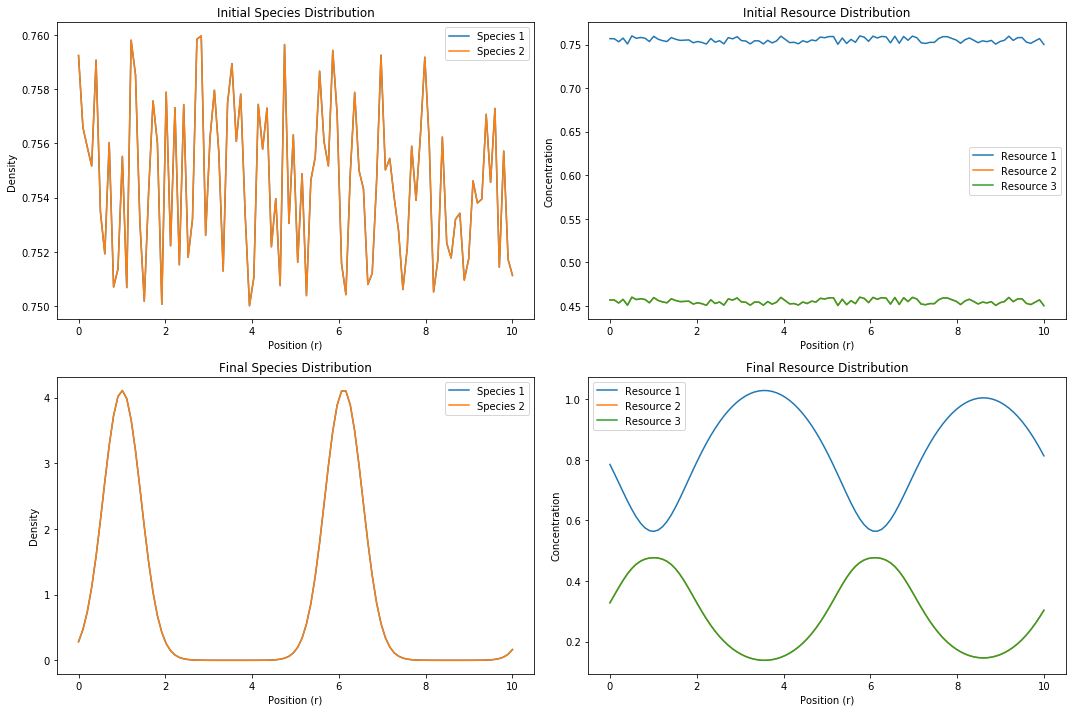

In [7]:
# Plot initial and final states
plt.figure(figsize=(15, 10))

# Plot initial state
plt.subplot(2, 2, 1)
for i in range(S):
    plt.plot(x, N_solutions[0, i], label=f'Species {i+1}')
plt.title('Initial Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 2)
for alpha in range(M):
    plt.plot(x, R_solutions[0, alpha], label=f'Resource {alpha+1}')
plt.title('Initial Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

# Plot final state
plt.subplot(2, 2, 3)
for i in range(S):
    plt.plot(x, N_solutions[-1, i], label=f'Species {i+1}')
plt.title('Final Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 4)
for alpha in range(M):
    plt.plot(x, R_solutions[-1, alpha], label=f'Resource {alpha+1}')
plt.title('Final Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

plt.tight_layout()
#plt.savefig('1D_pde_solution_190325.png')
plt.show()

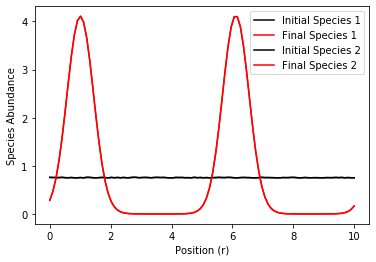

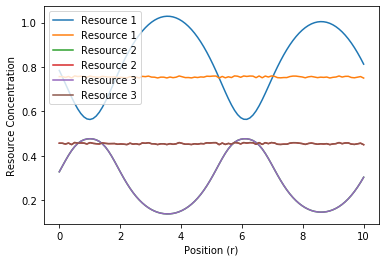

In [12]:
colors = ['k','r']
for i in range(S):
    plt.plot(x, N_solutions[0, i],c=colors[0], label=f'Initial Species {i+1}')
    plt.plot(x, N_solutions[-1, i],c=colors[1], label=f'Final Species {i+1}')
#plt.title('Initial Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Species Abundance')
plt.legend()
plt.show()


colors = ['k','r']
for alpha in range(M):
    plt.plot(x, R_solutions[-1, alpha], label=f'Resource {alpha+1}')
    plt.plot(x, R_solutions[0, alpha], label=f'Resource {alpha+1}')
#plt.title('Final Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Resource Concentration')
plt.legend()
plt.show()

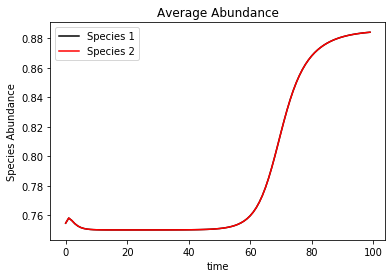

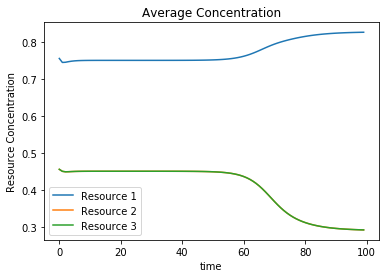

In [20]:
stride = 1000
for i in range(S):
    plt.plot(t[::stride], np.mean(N_solutions[::stride, i],axis = -1), c=colors[i], label=f'Species {i+1}')
plt.title('Average Abundance')
plt.xlabel('time')
plt.ylabel('Species Abundance')
plt.legend()
plt.show()


stride = 1000
for i in range(M):
    plt.plot(t[::stride], np.mean(R_solutions[::stride, i],axis = -1), label=f'Resource {i+1}')
plt.title('Average Concentration')
plt.xlabel('time')
plt.ylabel('Resource Concentration')
plt.legend()
plt.show()

In [16]:
print(np.shape(N_solutions))

(100000, 2, 100)
